In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [26]:
df = pd.read_pickle(Path(os.getcwd()).parent / "datos" / "intermedios" / "tablo_analitico.pkl")

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 136472 entries, 0 to 136475
Data columns (total 11 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   fecha_hora               136472 non-null  datetime64[us]
 1   id_planta                136472 non-null  object        
 2   id_inversor              136472 non-null  object        
 3   potencia_dc_kw           136472 non-null  float64       
 4   potencia_ac_kw           136472 non-null  float64       
 5   energia_diaria_kwh       136472 non-null  float64       
 6   energia_total_kwh        136472 non-null  float64       
 7   id_sensor_meteorologico  136472 non-null  object        
 8   temperatura_ambiente_c   136472 non-null  float64       
 9   temperatura_modulo_c     136472 non-null  float64       
 10  irradiacion_wh_m2        136472 non-null  float64       
dtypes: datetime64[us](1), float64(7), object(3)
memory usage: 12.5+ MB


In [30]:
df.head()

,fecha_hora,id_planta,id_inversor,potencia_dc_kw,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh,id_sensor_meteorologico,temperatura_ambiente_c,temperatura_modulo_c,irradiacion_wh_m2,mes,dia,time,hora,minuto
0,2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,sensor_p1,25.184316,22.857507,0.0,5,15,00:00:00,0,0
1,2020-05-15,p1,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,sensor_p1,25.184316,22.857507,0.0,5,15,00:00:00,0,0
2,2020-05-15,p1,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,sensor_p1,25.184316,22.857507,0.0,5,15,00:00:00,0,0
3,2020-05-15,p1,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,sensor_p1,25.184316,22.857507,0.0,5,15,00:00:00,0,0
4,2020-05-15,p1,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,sensor_p1,25.184316,22.857507,0.0,5,15,00:00:00,0,0


In [29]:
# Extraer componentes de fecha_hora
df['mes'] = df['fecha_hora'].dt.month
df['dia'] = df['fecha_hora'].dt.day
df['time'] = df['fecha_hora'].dt.time
df['hora'] = df['fecha_hora'].dt.hour
df['minuto'] = df['fecha_hora'].dt.minute

# Verificar las nuevas variables
df[['fecha_hora', 'mes', 'dia', 'time', 'hora', 'minuto']].head()

,fecha_hora,mes,dia,time,hora,minuto
0,2020-05-15,5,15,00:00:00,0,0
1,2020-05-15,5,15,00:00:00,0,0
2,2020-05-15,5,15,00:00:00,0,0
3,2020-05-15,5,15,00:00:00,0,0
4,2020-05-15,5,15,00:00:00,0,0


In [31]:
# pasar fecha_hora a indice
df.set_index('fecha_hora', inplace=True)

In [32]:
def eficiencia_inverter(dc, ac):
    temp = np.where(dc > 0 , ac / dc, 1) * 100
    return np.where(temp > 100, 100, temp)

In [33]:
df['eficiencia'] = eficiencia_inverter(df['potencia_dc_kw'], df['potencia_ac_kw'])

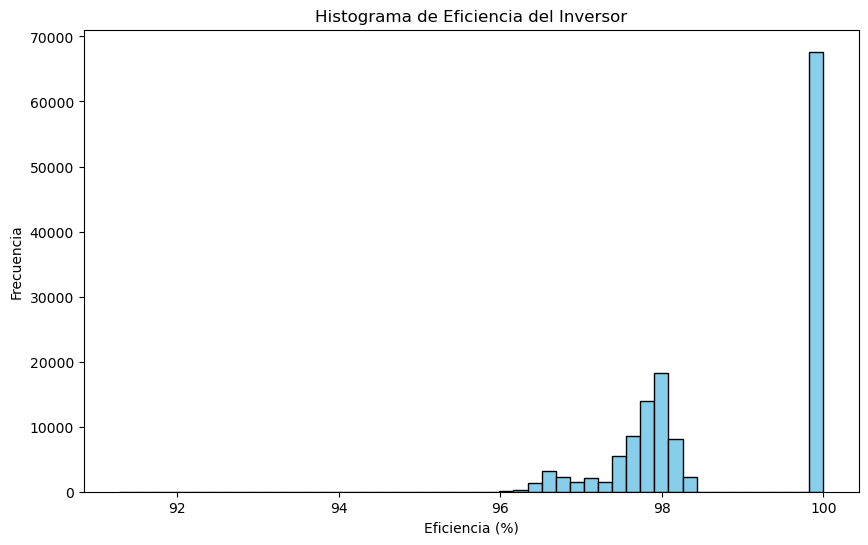

In [34]:
# histograma de eficiencia
plt.figure(figsize=(10, 6))
plt.hist(df['eficiencia'], bins=50, color='skyblue', edgecolor='black')
plt.title('Histograma de Eficiencia del Inversor')
plt.xlabel('Eficiencia (%)')
plt.ylabel('Frecuencia')
plt.show()

In [39]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 136472 entries, 2020-05-15 00:00:00 to 2020-06-17 23:45:00
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_planta                136472 non-null  object 
 1   id_inversor              136472 non-null  object 
 2   id_sensor_meteorologico  136472 non-null  object 
 3   mes                      136472 non-null  int32  
 4   dia                      136472 non-null  int32  
 5   time                     136472 non-null  object 
 6   hora                     136472 non-null  int32  
 7   minuto                   136472 non-null  int32  
 8   irradiacion_wh_m2        136472 non-null  float64
 9   temperatura_ambiente_c   136472 non-null  float64
 10  temperatura_modulo_c     136472 non-null  float64
 11  potencia_dc_kw           136472 non-null  float64
 12  eficiencia               136472 non-null  float64
 13  potencia_ac_kw           136472 non-

In [40]:
orden = ['id_planta', 'id_inversor', 'id_sensor_meteorologico', 'mes', 'dia', 'time', 'hora', 'minuto','irradiacion_wh_m2', 'temperatura_ambiente_c', 'temperatura_modulo_c', 'potencia_dc_kw', 'eficiencia', 'potencia_ac_kw', 'energia_diaria_kwh', 'energia_total_kwh']

In [41]:
df = df[orden]

In [42]:
df.head()

,id_planta,id_inversor,id_sensor_meteorologico,mes,dia,time,hora,minuto,irradiacion_wh_m2,temperatura_ambiente_c,temperatura_modulo_c,potencia_dc_kw,eficiencia,potencia_ac_kw,energia_diaria_kwh,energia_total_kwh
fecha_hora,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6259559.0
2020-05-15,p1,1IF53ai7Xc0U56Y,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6183645.0
2020-05-15,p1,3PZuoBAID5Wc2HD,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,6987759.0
2020-05-15,p1,7JYdWkrLSPkdwr4,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7602960.0
2020-05-15,p1,McdE0feGgRqW7Ca,sensor_p1,5,15,00:00:00,0,0,0.0,25.184316,22.857507,0.0,100.0,0.0,0.0,7158964.0


In [44]:
df_dia = df.groupby(['id_planta', 'id_inversor']).resample('D').agg({
    'irradiacion_wh_m2': ['min','mean','max','sum'],
    'temperatura_ambiente_c': ['min','mean','max'],
    'temperatura_modulo_c': ['min','mean','max'],
    'potencia_dc_kw': ['min','mean','max'],
    'eficiencia': ['min','mean','max'],
    'potencia_ac_kw': ['min','mean','max'],
    'energia_diaria_kwh': ['min','mean','max'],
    'energia_total_kwh': ['min','mean','max'],
    })

In [47]:
df_dia.columns = ['_'.join(col) for col in df_dia.columns]

In [51]:
df_dia = df_dia.reset_index(level=['id_planta', 'id_inversor'])

In [52]:
df_dia = df_dia.reset_index()
df_dia = df_dia.set_index('fecha_hora')

In [54]:
df_dia.head()

,id_planta,id_inversor,irradiacion_wh_m2_min,irradiacion_wh_m2_mean,irradiacion_wh_m2_max,irradiacion_wh_m2_sum,temperatura_ambiente_c_min,temperatura_ambiente_c_mean,temperatura_ambiente_c_max,temperatura_modulo_c_min,...,eficiencia_max,potencia_ac_kw_min,potencia_ac_kw_mean,potencia_ac_kw_max,energia_diaria_kwh_min,energia_diaria_kwh_mean,energia_diaria_kwh_max,energia_total_kwh_min,energia_total_kwh_mean,energia_total_kwh_max
fecha_hora,,,,,,,,,,,,,,,,,,,,,
2020-05-15,p1,1BY6WEcLGh8j5v7,0.0,0.204699,0.893661,19.037010,22.037482,27.430823,34.430943,20.290726,...,100.0,0.0,247.812372,1039.350000,0.0,2641.120776,5754.0,6259559.0,6.262200e+06,6265313.0
2020-05-16,p1,1BY6WEcLGh8j5v7,0.0,0.211951,0.812241,18.651690,21.496287,26.780538,32.524149,19.592692,...,100.0,0.0,285.505580,1095.285714,0.0,3380.406047,6292.0,6265313.0,6.268693e+06,6271605.0
2020-05-17,p1,1BY6WEcLGh8j5v7,0.0,0.238869,0.997904,22.931378,21.209418,26.686727,35.252486,20.377121,...,100.0,0.0,293.467187,1114.814286,0.0,3473.035714,7045.0,6271605.0,6.275078e+06,6278650.0
2020-05-18,p1,1BY6WEcLGh8j5v7,0.0,0.159026,0.971481,15.266485,20.961525,23.850938,28.367100,19.477531,...,100.0,0.0,208.026116,1193.628571,0.0,2271.423549,4998.0,6278650.0,6.280921e+06,6283648.0
2020-05-19,p1,1BY6WEcLGh8j5v7,0.0,0.194031,0.835832,18.044861,22.388784,25.338021,30.368632,20.062144,...,100.0,0.0,244.528783,1059.800000,0.0,3087.064900,6449.0,6283648.0,6.286728e+06,6290097.0


In [55]:
df.to_pickle(Path(os.getcwd()).parent / "datos" / "intermedios" / "tablo_analitico_preparado.pkl")
df_dia.to_pickle(Path(os.getcwd()).parent / "datos" / "intermedios" / "tablo_analitico_dia.pkl")